In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(1)   # makes the numbers the same every time you run it

dates = pd.date_range(start="2026-01-01", periods=120, freq="B")  # B = business days
 
def make_prices(starting_price):
    """Create a realistic-looking price path."""
    daily_change = np.random.normal(0.0005, 0.015, 120)
    return starting_price * (1 + daily_change).cumprod()
 
df = pd.DataFrame({
    "Apple":     make_prices(180),
    "Microsoft": make_prices(340),
    "Google":    make_prices(140),
}, index=dates)
 
print("We have", len(df), "days of data for", len(df.columns), "companies.")
df.head() 

We have 120 days of data for 3 companies.


,Apple,Microsoft,Google
2026-01-01,184.475732,340.044454,139.023752
2026-01-02,182.875157,336.260635,138.444749
2026-01-05,181.517752,342.853475,138.510043
2026-01-06,178.687068,353.141316,135.677609
2026-01-07,181.095969,343.475935,133.992528


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())
 
print("\nAny negative prices? (prices can never be negative)")
print((df < 0).sum())
 
print("\nBasic statistics:")
df.describe().round(2)

Missing values in each column:
Apple        0
Microsoft    0
Google       0
dtype: int64

Any negative prices? (prices can never be negative)
Apple        0
Microsoft    0
Google       0
dtype: int64

Basic statistics:


,Apple,Microsoft,Google
count,120.00,120.00,120.00
mean,188.23,404.52,147.29
std,13.29,41.27,8.28
min,166.39,336.26,130.32
25%,176.36,367.42,141.36
50%,185.14,399.47,146.83
75%,200.75,439.45,150.27
max,211.30,483.28,167.70


In [4]:
returns = df.pct_change()      # pandas does the maths for us
returns = returns.dropna()     # the first row has no "yesterday", so drop it
 
print("Daily returns (as decimals, 0.02 = 2%):")
returns.head()

Daily returns (as decimals, 0.02 = 2%):


,Apple,Microsoft,Google
2026-01-02,-0.008676,-0.011127,-0.004165
2026-01-05,-0.007423,0.019606,0.000472
2026-01-06,-0.015595,0.030007,-0.020449
2026-01-07,0.013481,-0.027370,-0.012420
2026-01-08,-0.034023,0.019042,0.010621


In [5]:
summary = pd.DataFrame({
    "Starting Price": df.iloc[0].round(2),
    "Ending Price":   df.iloc[-1].round(2),
    "Total Change %": ((df.iloc[-1] / df.iloc[0] - 1) * 100).round(2),
    "Average Daily Return %": (returns.mean() * 100).round(3),
    "Risk (Std Dev) %": (returns.std() * 100).round(2),
})
 
print("SUMMARY OF ALL THREE STOCKS")
print(summary.to_string())

SUMMARY OF ALL THREE STOCKS
           Starting Price  Ending Price  Total Change %  Average Daily Return %  Risk (Std Dev) %
Apple              184.48        201.75            9.36                   0.084              1.31
Microsoft          340.04        455.81           34.05                   0.258              1.54
Google             139.02        146.85            5.63                   0.057              1.48


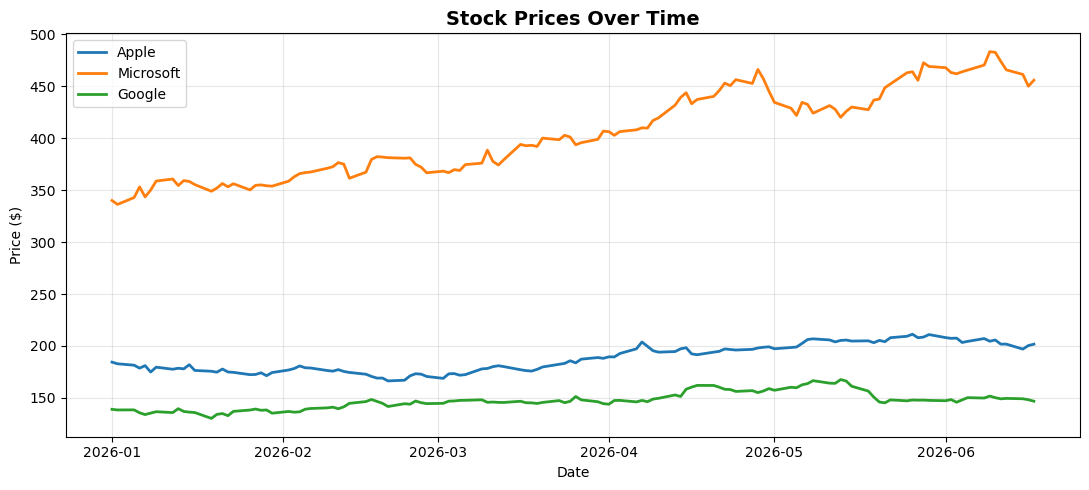

In [6]:
plt.figure(figsize=(11, 5))
 
for company in df.columns:
    plt.plot(df.index, df[company], label=company, linewidth=2)
 
plt.title("Stock Prices Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

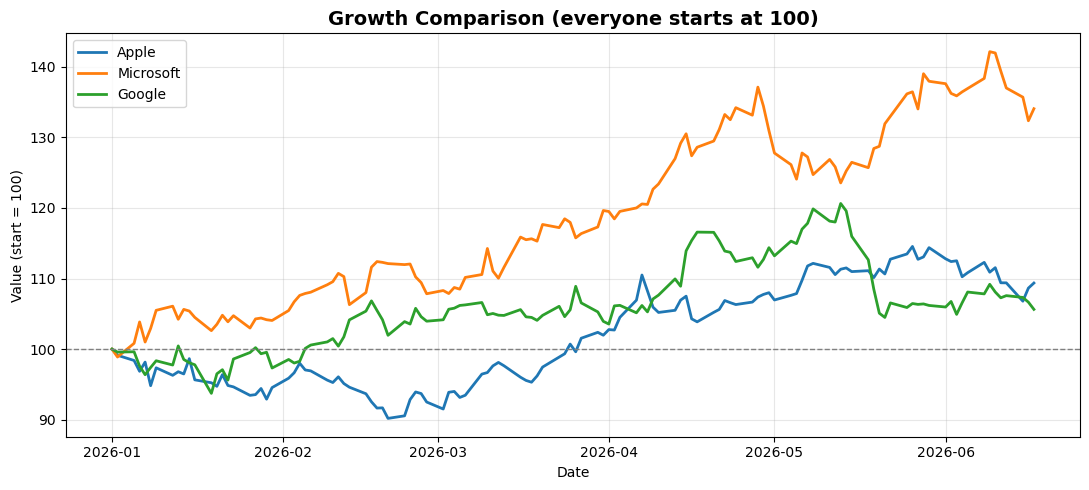

In [7]:
normalised = df / df.iloc[0] * 100
 
plt.figure(figsize=(11, 5))
for company in normalised.columns:
    plt.plot(normalised.index, normalised[company], label=company, linewidth=2)
 
plt.axhline(100, color="grey", linestyle="--", linewidth=1)  # the starting line
plt.title("Growth Comparison (everyone starts at 100)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Value (start = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

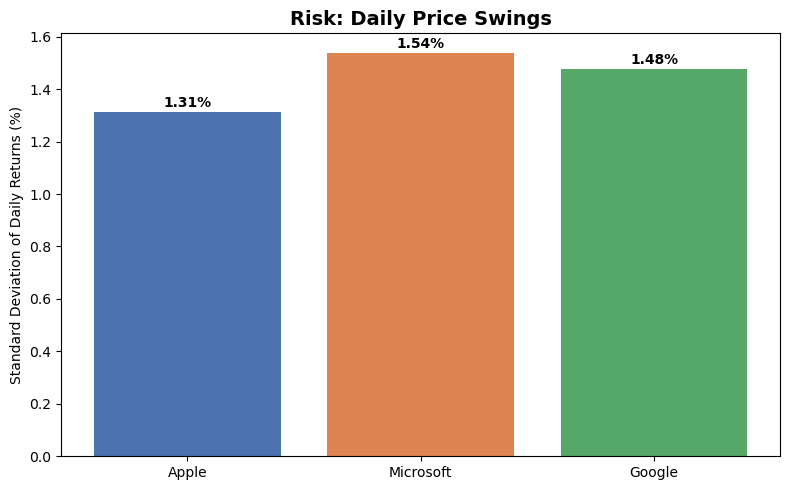

In [8]:
risk = returns.std() * 100
 
plt.figure(figsize=(8, 5))
bars = plt.bar(risk.index, risk.values, color=["#4C72B0", "#DD8452", "#55A868"])
 
for bar, value in zip(bars, risk.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.02,
             f"{value:.2f}%", ha="center", fontweight="bold")
 
plt.title("Risk: Daily Price Swings", fontsize=14, fontweight="bold")
plt.ylabel("Standard Deviation of Daily Returns (%)")
plt.tight_layout()
plt.show()

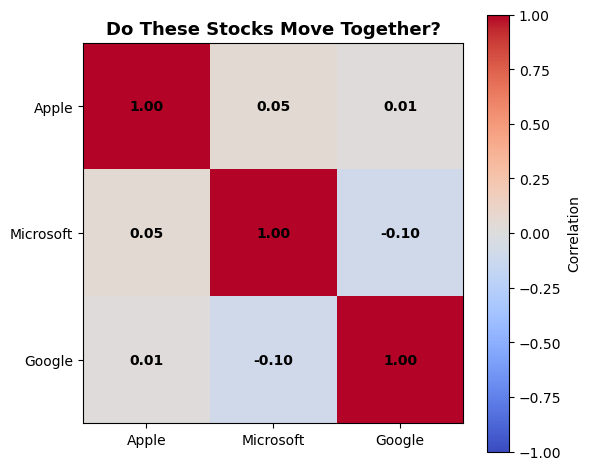


Correlation table:
           Apple  Microsoft  Google
Apple       1.00       0.05    0.01
Microsoft   0.05       1.00   -0.10
Google      0.01      -0.10    1.00


In [9]:
correlation = returns.corr()
 
plt.figure(figsize=(6, 5))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
 
# write the number inside each box
for i in range(len(correlation)):
    for j in range(len(correlation)):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}",
                 ha="center", va="center", fontweight="bold")
 
plt.xticks(range(len(correlation)), correlation.columns)
plt.yticks(range(len(correlation)), correlation.columns)
plt.title("Do These Stocks Move Together?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
 
print("\nCorrelation table:")
print(correlation.round(2).to_string())

In [11]:
best  = summary["Total Change %"].idxmax()
worst = summary["Total Change %"].idxmin()
safest = summary["Risk (Std Dev) %"].idxmin()
 
print("=" * 50)
print("           FINAL REPORT")
print("=" * 50)
print(f"Best performer   : {best}  ({summary.loc[best, 'Total Change %']}%)")
print(f"Worst performer  : {worst}  ({summary.loc[worst, 'Total Change %']}%)")
print(f"Least risky      : {safest}  ({summary.loc[safest, 'Risk (Std Dev) %']}% daily swing)")
print("=" * 50)

           FINAL REPORT
Best performer   : Microsoft  (34.05%)
Worst performer  : Google  (5.63%)
Least risky      : Apple  (1.31% daily swing)
